In [118]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

import aux
import rocky
import environments

## Task description

In [101]:
# =================================================================================
# Task: Balancing an upright pole on a moving cart (CartPole)
# =================================================================================

# System parameters
m = 1.0                                   # Mass of the pole
M = 5.0                                   # Mass of the cart
l = 1.0                                   # Length of the pole
g = 9.8                                   # Acceleration due to gravity
d = 1                                     # Damping factor
dt = 0.01                                 # time step (for discrete dynamics)

# Transition dynamics
A = np.eye(4) + dt * np.array([[0,        1,                 0,              0],
                               [0,     - d / M,         - m * g / M,         0],
                               [0,        0,                 0,              1],
                               [0,   d / (M * l),   (m + M) * g / (M * l),   0]])

# Motor responsiveness
B = dt * np.array([[0], [1/M], [0], [-1 / (M * l)]])

H = np.eye(A.shape[0])

dim_labels = ["x", "v", "theta", "omega"]
dim_s, dim_o, dim_m, dim_u = A.shape[0], H.shape[0], H.shape[1], B.shape[1]

# Actions:
# u := adjustments to cart's acceleration

# Signal-to-noise ratio:
# Accurate measurements of positions, unreliable measurements of velocities
Q = np.diag([0.001, 0.001, np.deg2rad(1)**2, np.deg2rad(1)**2]) * dt

# Observation noise covariance
R = np.diag([0.01, 0.05, 0.005**2, 0.03**2]) * dt

# Cost function:
# Agent's goal: keeping the pole upright (x=0, theta=0)
# State deviation penalty: Cost per unit of deviation along the state dimensions
Cs = 500 * np.eye(dim_s)
# Motion penalty: Cost per unit of motion
Cu = 1 * np.eye(dim_u)
# Inference penalty: Cost per bit of information encoded in the belief
Cb = .1

task_description = {"model": [A, B, H, Q, R], "cost_rate":[Cs, Cu, Cb], "angles":[]}

### Optimal inference and control policy when information is free

In [102]:
lqg_policy = aux.solve_lqg(task_description)
S, _, Sigma = aux.buildSigma(lqg_policy, task_description, show_res = True)


Expected costs at equilibrium:
SC = 5.8934, UC = 2.5390, IC = 13.4682, ERR = 0.0001, Loss = 9.7793


### Optimal inference and control policy when information is costly

In [103]:
torch_description = rocky.desc2tensor(task_description)
solver = rocky.Solver(torch_description)
x0 = rocky.initialize(lqg_policy)

In [109]:
res = solver.minimize(res["x"],
            tol=1e-3,
            curvature_tol=1e-3,
            adam_lr=1e-6,
            max_steps=1000000,
            hessian_every=25,
            newton_gradient_threshold=10.0,
            relative_damping=1e-5,
            absolute_damping=1e-8,
            maximum_newton_step=1.0,
            armijo_constant=1e-4,
            backtracking_factor=0.5,
            max_backtracks=30,
            print_every=100,)

In [110]:
print(f"Optimization converged?: {res["converged"]}, gradient norm: {res["gradient_norm"]:.4f}, min hessian eigenvalue: {res["min_hessian_eigenvalue"]:.4f}")

Optimization converged?: True, gradient norm: 0.0010, min hessian eigenvalue: -0.0009


In [111]:
task_description["solution"] = res["x"].numpy()

with open("../solutions/cart-pole.pkl", "wb") as file:
    pickle.dump(task_description, file)

In [113]:
frugal_policy = solver.cast_solution()
_, _, lqg_costs = aux.buildSigma(lqg_policy, task_description)
_, _, frugal_costs = aux.buildSigma(frugal_policy, task_description, show_res = True)

discarded_info = (lqg_costs[2] - frugal_costs[2]) * 100 / lqg_costs[2]

lqg_performance = lqg_costs[0] + lqg_costs[1]
frugal_performance = frugal_costs[0] + frugal_costs[1]
sacrificed_performance = (frugal_performance - lqg_performance) * 100 / lqg_performance

print(f"\nFrugal agent discarded {discarded_info:.2f}% of the information in the Bayes-optimal belief while sacrificing only {sacrificed_performance:.2f}% of task performance")


Expected costs at equilibrium:
SC = 6.0699, UC = 2.6331, IC = 1.4991, ERR = 0.0157, Loss = 8.8529

Frugal agent discarded 88.87% of the information in the Bayes-optimal belief while sacrificing only 3.21% of task performance


### Nonlinear simulations

In [116]:
horizon=2000
num_rollouts = 100

init_s = np.array([[1., 0., 20 * np.pi / 180, 0]]*num_rollouts).T
env = environments.CartPole(m, M, l, g, d, dt, H, Q, R, init_s, horizon = horizon, num_rollouts = num_rollouts)

lqg_taus, lqg_costs = environments.simulate(lqg_policy, task_description, env, horizon=horizon, num_rollouts=num_rollouts)
frugal_taus, frugal_costs = environments.simulate(frugal_policy, task_description, env, horizon=horizon, num_rollouts=num_rollouts)

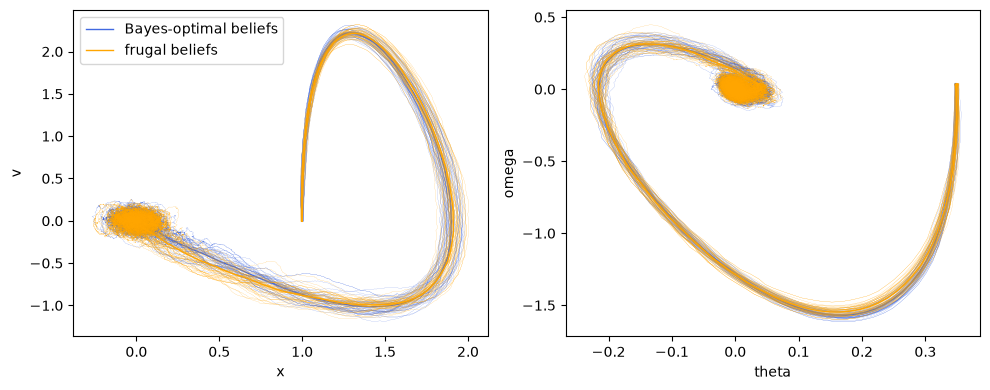

In [117]:
samples = np.random.choice(num_rollouts, 50)
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(lqg_taus["states"][:, 0, samples], lqg_taus["states"][:, 1, samples], linewidth=.1, color="royalblue")
axs[0].plot(np.mean(lqg_taus["states"][:, 0, samples], axis=-1), np.mean(lqg_taus["states"][:, 1, samples], axis=-1), linewidth=1, color="royalblue", label="Bayes-optimal beliefs")

axs[0].plot(frugal_taus["states"][:, 0, samples], frugal_taus["states"][:, 1, samples], linewidth=.1, color="orange")
axs[0].plot(np.mean(frugal_taus["states"][:, 0, samples], axis=-1), np.mean(frugal_taus["states"][:, 1, samples], axis=-1), linewidth=1, color="orange", label="frugal beliefs")

axs[0].set_xlabel(dim_labels[0])
axs[0].set_ylabel(dim_labels[1])

axs[1].plot(lqg_taus["states"][:, 2, samples], lqg_taus["states"][:, 3, samples], linewidth=.1, color="royalblue")
axs[1].plot(np.mean(lqg_taus["states"][:, 2, samples], axis=-1), np.mean(lqg_taus["states"][:, 3, samples], axis=-1), linewidth=1, color="royalblue")

axs[1].plot(frugal_taus["states"][:, 2, samples], frugal_taus["states"][:, 3, samples], linewidth=.1, color="orange")
axs[1].plot(np.mean(frugal_taus["states"][:, 2, samples], axis=-1), np.mean(frugal_taus["states"][:, 3, samples], axis=-1), linewidth=1, color="orange")

axs[1].set_xlabel(dim_labels[2])
axs[1].set_ylabel(dim_labels[3])

axs[0].legend()
plt.tight_layout()
plt.show()